# Notebook 04: Feature Engineering
## DATATHON 2026 — The Gridbreaker

**Mục tiêu:** Tạo feature set hoàn chỉnh cho Sales Forecasting Model

---

### Feature Categories
| # | Category | Ví dụ | Nguồn |
|---|----------|-------|-------|
| 1 | Calendar / Seasonal | Month, DoW, is_holiday, quarter | order_date |
| 2 | Lag Features | Revenue_lag_1, Revenue_lag_7, Revenue_lag_30 | target |
| 3 | Rolling Statistics | Revenue_MA_7, Revenue_MA_30, Revenue_std_7 | target |
| 4 | Fourier Terms | sin/cos cho seasonal patterns | order_date |
| 5 | Product Mix | Category share, avg_price, segment breakdown | products + items |
| 6 | Customer / Demand | N_active_customers, new_vs_returning | customers + orders |
| 7 | External Signals | Web traffic, promo intensity, inventory level | web/promo/inventory |

### Nguyên tắc
- **KHÔNG sử dụng thông tin tương lai** — Lag features phải > 0
- Tất cả features tính trên **Training Set** (2012–2021)
- Output: DataFrame daily features sẵn sàng cho modeling

---
## 1. Import & Build Base Table

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 11, 'figure.dpi': 100})

DATA_DIR   = '../dataset/'
TRAIN_END  = '2021-12-31'
VAL_START  = '2022-01-01'

print('Import thành công!')

Import thành công!


In [2]:
# === Load all data ===
products    = pd.read_csv(DATA_DIR + 'products.csv')
customers   = pd.read_csv(DATA_DIR + 'customers.csv', parse_dates=['signup_date'])
orders      = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR + 'order_items.csv')
payments    = pd.read_csv(DATA_DIR + 'payments.csv')
promotions  = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date', 'end_date'])
geography   = pd.read_csv(DATA_DIR + 'geography.csv')
shipments   = pd.read_csv(DATA_DIR + 'shipments.csv', parse_dates=['ship_date', 'delivery_date'])
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv', parse_dates=['date'])
inventory   = pd.read_csv(DATA_DIR + 'inventory.csv', parse_dates=['snapshot_date'])

# Training set
train_orders = orders[orders['order_date'] <= TRAIN_END].copy()
train_order_ids = set(train_orders['order_id'])
train_items = order_items[order_items['order_id'].isin(train_order_ids)].copy()

# Revenue calc
train_items['revenue'] = train_items['quantity'] * train_items['unit_price']
train_items['cogs_total'] = train_items.merge(
    products[['product_id', 'cogs']], on='product_id', how='left'
)['cogs'] * train_items['quantity']
train_items['gross_profit'] = train_items['revenue'] - train_items['cogs_total']

train_items = train_items.merge(
    train_orders[['order_id', 'order_date', 'order_status', 'customer_id']],
    on='order_id', how='left'
)

# Delivered items only
delivered = train_items[train_items['order_status'] == 'delivered'].copy()

print(f'Data loaded: {len(delivered):,} delivered items')

Data loaded: 541,644 delivered items


In [3]:
# === Build Base Daily Table (Target) ===
daily_base = delivered.groupby(
    delivered['order_date'].dt.date
).agg(
    revenue=('revenue', 'sum'),
    cogs=('cogs_total', 'sum'),
    profit=('gross_profit', 'sum'),
    items_sold=('quantity', 'sum'),
    n_orders=('order_id', 'nunique'),
    n_customers=('customer_id', 'nunique'),
    avg_discount=('discount_amount', 'mean'),
    total_discount=('discount_amount', 'sum'),
    promo_rate=('promo_id', lambda x: x.notna().mean())
).reset_index()

daily_base.columns = ['date', 'revenue', 'cogs', 'profit', 'items_sold',
                       'n_orders', 'n_customers', 'avg_discount', 'total_discount', 'promo_rate']
daily_base['date'] = pd.to_datetime(daily_base['date'])

# Fill missing dates with 0
date_range = pd.date_range(daily_base['date'].min(), daily_base['date'].max(), freq='D')
daily_base = daily_base.set_index('date').reindex(date_range, fill_value=0).reset_index()
daily_base.rename(columns={'index': 'date'}, inplace=True)

# Derived
daily_base['aov'] = np.where(daily_base['n_orders'] > 0,
                              daily_base['revenue'] / daily_base['n_orders'], 0)
daily_base['items_per_order'] = np.where(daily_base['n_orders'] > 0,
                                          daily_base['items_sold'] / daily_base['n_orders'], 0)

print(f'Base table: {len(daily_base)} days')
print(f'   Period: {daily_base.date.min().date()} → {daily_base.date.max().date()}')
daily_base.head()

Base table: 3468 days
   Period: 2012-07-04 → 2021-12-31


,date,revenue,cogs,profit,items_sold,n_orders,n_customers,avg_discount,total_discount,promo_rate,aov,items_per_order
0,2012-07-04,4523077.12,3.520205e+06,1.002872e+06,667,134,134,0.0,0.0,0.0,33754.306866,4.977612
1,2012-07-05,2359033.28,1.839385e+06,5.196488e+05,358,81,81,0.0,0.0,0.0,29123.867654,4.419753
2,2012-07-06,2175146.51,1.795393e+06,3.797538e+05,319,69,69,0.0,0.0,0.0,31523.862464,4.623188
3,2012-07-07,1901346.25,1.522311e+06,3.790357e+05,264,55,55,0.0,0.0,0.0,34569.931818,4.800000
4,2012-07-08,1782827.51,1.348103e+06,4.347240e+05,309,67,67,0.0,0.0,0.0,26609.365821,4.611940


---
## 2. Calendar & Seasonal Features

In [4]:
df = daily_base.copy()

# === Calendar Features ===
df['year']          = df['date'].dt.year
df['month']         = df['date'].dt.month
df['quarter']       = df['date'].dt.quarter
df['day_of_week']   = df['date'].dt.dayofweek    # 0=Mon, 6=Sun
df['day_of_month']  = df['date'].dt.day
df['day_of_year']   = df['date'].dt.dayofyear
df['week_of_year']  = df['date'].dt.isocalendar().week.astype(int)
df['is_weekend']    = df['day_of_week'].isin([5, 6]).astype(int)
df['is_month_start']= df['date'].dt.is_month_start.astype(int)
df['is_month_end']  = df['date'].dt.is_month_end.astype(int)
df['is_quarter_start'] = df['date'].dt.is_quarter_start.astype(int)
df['is_quarter_end']   = df['date'].dt.is_quarter_end.astype(int)

# Week of month (1-5)
df['week_of_month'] = (df['day_of_month'] - 1) // 7 + 1

# Season (Vietnam-specific: hot/rainy/cool)
def vietnam_season(month):
    if month in [3, 4, 5, 6, 7, 8]:
        return 'hot_rainy'  # Mùa nóng/mưa
    elif month in [9, 10, 11]:
        return 'cool'       # Mùa mát
    else:
        return 'cold'       # Mùa lạnh (Tết)

df['season'] = df['month'].apply(vietnam_season)

# Tet holiday proxy (around Jan-Feb)
# Note: Exact Tet dates vary by year, this is an approximation
df['is_tet_season'] = ((df['month'] == 1) & (df['day_of_month'] >= 15) | 
                        (df['month'] == 2) & (df['day_of_month'] <= 15)).astype(int)

# Shopping events (11.11, 12.12, Black Friday approximation)
df['is_1111'] = ((df['month'] == 11) & (df['day_of_month'].between(9, 13))).astype(int)
df['is_1212'] = ((df['month'] == 12) & (df['day_of_month'].between(10, 14))).astype(int)

calendar_cols = ['year', 'month', 'quarter', 'day_of_week', 'day_of_month', 'day_of_year',
                 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end',
                 'is_quarter_start', 'is_quarter_end', 'week_of_month',
                 'is_tet_season', 'is_1111', 'is_1212']

print(f'Calendar features: {len(calendar_cols)} columns')
print(f'   {calendar_cols}')

Calendar features: 16 columns
   ['year', 'month', 'quarter', 'day_of_week', 'day_of_month', 'day_of_year', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'week_of_month', 'is_tet_season', 'is_1111', 'is_1212']


---
## 3. Lag Features

**Quan trọng nhất** cho time-series forecasting — giá trị quá khứ dự đoán tương lai.

> Mọi lag phải ≥ 1 (không được dùng giá trị hiện tại/tương lai)

In [5]:
# === Lag Features ===
lag_targets = ['revenue', 'n_orders', 'items_sold', 'aov']
lag_days = [1, 2, 3, 7, 14, 21, 28, 30, 60, 90, 365]  # Various horizons

lag_cols = []
for target in lag_targets:
    for lag in lag_days:
        col_name = f'{target}_lag_{lag}'
        df[col_name] = df[target].shift(lag)
        lag_cols.append(col_name)

# Same day last week, last month, last year
df['revenue_same_dow_last_week'] = df['revenue'].shift(7)
df['revenue_same_dom_last_month'] = df['revenue'].shift(30)  # Approximate
df['revenue_same_day_last_year'] = df['revenue'].shift(365)
lag_cols.extend(['revenue_same_dow_last_week', 'revenue_same_dom_last_month', 'revenue_same_day_last_year'])

# Diff features (change from lag)
df['revenue_diff_1'] = df['revenue'] - df['revenue'].shift(1)
df['revenue_diff_7'] = df['revenue'] - df['revenue'].shift(7)
df['revenue_diff_30'] = df['revenue'] - df['revenue'].shift(30)
lag_cols.extend(['revenue_diff_1', 'revenue_diff_7', 'revenue_diff_30'])

# Pct change
df['revenue_pct_change_1'] = df['revenue'].pct_change(1).replace([np.inf, -np.inf], np.nan)
df['revenue_pct_change_7'] = df['revenue'].pct_change(7).replace([np.inf, -np.inf], np.nan)
lag_cols.extend(['revenue_pct_change_1', 'revenue_pct_change_7'])

print(f'Lag features: {len(lag_cols)} columns')

Lag features: 52 columns


---
## 4. Rolling Statistics

In [6]:
# === Rolling Window Statistics ===
rolling_targets = ['revenue', 'n_orders', 'items_sold']
windows = [3, 7, 14, 30, 60, 90]

rolling_cols = []
for target in rolling_targets:
    for w in windows:
        # Mean (shifted by 1 to avoid leakage)
        col = f'{target}_ma_{w}'
        df[col] = df[target].shift(1).rolling(w, min_periods=1).mean()
        rolling_cols.append(col)
        
        # Std
        col = f'{target}_std_{w}'
        df[col] = df[target].shift(1).rolling(w, min_periods=1).std()
        rolling_cols.append(col)
        
        # Min/Max (chỉ cho revenue)
        if target == 'revenue':
            col_min = f'{target}_min_{w}'
            col_max = f'{target}_max_{w}'
            df[col_min] = df[target].shift(1).rolling(w, min_periods=1).min()
            df[col_max] = df[target].shift(1).rolling(w, min_periods=1).max()
            rolling_cols.extend([col_min, col_max])

# Expanding mean (cumulative average up to yesterday)
df['revenue_expanding_mean'] = df['revenue'].shift(1).expanding(min_periods=1).mean()
rolling_cols.append('revenue_expanding_mean')

# Exponential weighted mean
for span in [7, 30]:
    col = f'revenue_ewm_{span}'
    df[col] = df['revenue'].shift(1).ewm(span=span, adjust=False).mean()
    rolling_cols.append(col)

# Coefficient of Variation
df['revenue_cv_30'] = df['revenue_std_30'] / df['revenue_ma_30'].replace(0, np.nan)
rolling_cols.append('revenue_cv_30')

print(f'Rolling features: {len(rolling_cols)} columns')

Rolling features: 52 columns


---
## 5. Fourier Terms (Seasonal Encoding)

Sin/Cos encoding cho seasonal patterns — hiệu quả hơn one-hot cho cyclical features.

In [7]:
# === Fourier Terms ===
fourier_cols = []

# Yearly seasonality (period = 365.25)
for k in range(1, 4):  # 3 harmonics
    col_sin = f'yearly_sin_{k}'
    col_cos = f'yearly_cos_{k}'
    df[col_sin] = np.sin(2 * np.pi * k * df['day_of_year'] / 365.25)
    df[col_cos] = np.cos(2 * np.pi * k * df['day_of_year'] / 365.25)
    fourier_cols.extend([col_sin, col_cos])

# Weekly seasonality (period = 7)
for k in range(1, 3):  # 2 harmonics
    col_sin = f'weekly_sin_{k}'
    col_cos = f'weekly_cos_{k}'
    df[col_sin] = np.sin(2 * np.pi * k * df['day_of_week'] / 7)
    df[col_cos] = np.cos(2 * np.pi * k * df['day_of_week'] / 7)
    fourier_cols.extend([col_sin, col_cos])

# Monthly seasonality (period = 30.44)
for k in range(1, 3):
    col_sin = f'monthly_sin_{k}'
    col_cos = f'monthly_cos_{k}'
    df[col_sin] = np.sin(2 * np.pi * k * df['day_of_month'] / 30.44)
    df[col_cos] = np.cos(2 * np.pi * k * df['day_of_month'] / 30.44)
    fourier_cols.extend([col_sin, col_cos])

print(f'Fourier features: {len(fourier_cols)} columns')

Fourier features: 14 columns


---
## 6. Product Mix & Customer Features

In [8]:
# === Product Mix Features (daily) ===
prod_items = delivered.merge(products[['product_id', 'category', 'segment', 'price']], 
                              on='product_id', how='left')

# Category revenue share (daily)
cat_daily = prod_items.groupby([prod_items['order_date'].dt.date, 'category'])['revenue'].sum().unstack(fill_value=0)
cat_daily.index = pd.to_datetime(cat_daily.index)
cat_daily = cat_daily.reindex(date_range, fill_value=0)
cat_total = cat_daily.sum(axis=1).replace(0, np.nan)

product_cols = []
for cat in cat_daily.columns:
    col = f'cat_share_{cat.lower().replace(" ", "_")}'
    # Shift by 1 to avoid leakage
    df[col] = (cat_daily[cat] / cat_total).shift(1).rolling(7, min_periods=1).mean().values
    product_cols.append(col)

# Segment revenue share (daily, lagged)
seg_daily = prod_items.groupby([prod_items['order_date'].dt.date, 'segment'])['revenue'].sum().unstack(fill_value=0)
seg_daily.index = pd.to_datetime(seg_daily.index)
seg_daily = seg_daily.reindex(date_range, fill_value=0)
seg_total = seg_daily.sum(axis=1).replace(0, np.nan)

for seg in seg_daily.columns:
    col = f'seg_share_{seg.lower().replace(" ", "_")}'
    df[col] = (seg_daily[seg] / seg_total).shift(1).rolling(7, min_periods=1).mean().values
    product_cols.append(col)

# Average price sold (7-day MA, lagged)
daily_avg_price = prod_items.groupby(prod_items['order_date'].dt.date)['unit_price'].mean()
daily_avg_price.index = pd.to_datetime(daily_avg_price.index)
daily_avg_price = daily_avg_price.reindex(date_range, fill_value=0)
df['avg_price_sold_ma7'] = daily_avg_price.shift(1).rolling(7, min_periods=1).mean().values
product_cols.append('avg_price_sold_ma7')

print(f'Product mix features: {len(product_cols)} columns')

Product mix features: 13 columns


In [9]:
# === Customer / Demand Features ===
customer_cols = []

# Daily active customers (lagged)
daily_cust = delivered.groupby(delivered['order_date'].dt.date)['customer_id'].nunique()
daily_cust.index = pd.to_datetime(daily_cust.index)
daily_cust = daily_cust.reindex(date_range, fill_value=0)

for w in [7, 30]:
    col = f'active_customers_ma_{w}'
    df[col] = daily_cust.shift(1).rolling(w, min_periods=1).mean().values
    customer_cols.append(col)

# New customer signups (lagged)
daily_signups = customers[customers['signup_date'] <= TRAIN_END].set_index('signup_date').resample('D').size()
daily_signups = daily_signups.reindex(date_range, fill_value=0)

for w in [7, 30]:
    col = f'new_signups_ma_{w}'
    df[col] = daily_signups.shift(1).rolling(w, min_periods=1).mean().values
    customer_cols.append(col)

# New vs Returning ratio (7-day lagged)
first_order = delivered.groupby('customer_id')['order_date'].min().reset_index()
first_order.columns = ['customer_id', 'first_order_date']
delivered_with_first = delivered.merge(first_order, on='customer_id', how='left')
delivered_with_first['is_new'] = (delivered_with_first['order_date'] == delivered_with_first['first_order_date']).astype(int)

daily_new_ratio = delivered_with_first.groupby(delivered_with_first['order_date'].dt.date)['is_new'].mean()
daily_new_ratio.index = pd.to_datetime(daily_new_ratio.index)
daily_new_ratio = daily_new_ratio.reindex(date_range, fill_value=0)
df['new_customer_ratio_ma7'] = daily_new_ratio.shift(1).rolling(7, min_periods=1).mean().values
customer_cols.append('new_customer_ratio_ma7')

print(f'Customer features: {len(customer_cols)} columns')

Customer features: 5 columns


---
## 7. External Signal Features

In [15]:
external_cols = []

# === Web Traffic Features ===
if 'visits' in web_traffic.columns:
    train_web = web_traffic[web_traffic['date'] <= TRAIN_END].copy()
    daily_visits = train_web.groupby('date')['visits'].sum()
    daily_visits = daily_visits.reindex(date_range, fill_value=0)
    
    for w in [1, 3, 7, 14, 30]:
        col = f'web_visits_lag_{w}' if w <= 3 else f'web_visits_ma_{w}'
        if w <= 3:
            df[col] = daily_visits.shift(w).values
        else:
            df[col] = daily_visits.shift(1).rolling(w, min_periods=1).mean().values
        external_cols.append(col)
    
    # Web traffic trend (MA7 / MA30)
    df['web_trend_ratio'] = (daily_visits.shift(1).rolling(7, min_periods=1).mean() / 
                              daily_visits.shift(1).rolling(30, min_periods=1).mean()).replace([np.inf, -np.inf], np.nan).values
    external_cols.append('web_trend_ratio')

# === Promotion Intensity ===
# Number of active promotions per day
def count_active_promos(date):
    return ((promotions['start_date'] <= date) & (promotions['end_date'] >= date)).sum()

active_promos = pd.Series([count_active_promos(d) for d in date_range], index=date_range)
df['n_active_promos'] = active_promos.values
df['n_active_promos_lag1'] = active_promos.shift(1).values
external_cols.extend(['n_active_promos', 'n_active_promos_lag1'])

# Promo rate (lagged)
for w in [7, 30]:
    col = f'promo_rate_ma_{w}'
    df[col] = df['promo_rate'].shift(1).rolling(w, min_periods=1).mean()
    external_cols.append(col)

# === Inventory Features ===
if 'stock_level' in inventory.columns:
    train_inv = inventory[inventory['date'] <= TRAIN_END].copy()
    daily_stock = train_inv.groupby('date')['stock_level'].sum()
    daily_stock = daily_stock.reindex(date_range, method='ffill').fillna(0)
    df['total_stock_lag1'] = daily_stock.shift(1).values
    df['stock_ma_7'] = daily_stock.shift(1).rolling(7, min_periods=1).mean().values
    external_cols.extend(['total_stock_lag1', 'stock_ma_7'])

print(f'External signal features: {len(external_cols)} columns')

External signal features: 4 columns


---
## 8. Feature Summary & Export

In [11]:
# === Feature Summary ===
all_feature_groups = {
    'Target & Base': ['revenue', 'cogs', 'profit', 'items_sold', 'n_orders', 
                      'n_customers', 'avg_discount', 'total_discount', 'promo_rate', 
                      'aov', 'items_per_order'],
    'Calendar': calendar_cols,
    'Lag': lag_cols,
    'Rolling': rolling_cols,
    'Fourier': fourier_cols,
    'Product Mix': product_cols,
    'Customer': customer_cols,
    'External': external_cols
}

print('='*60)
print('FEATURE ENGINEERING SUMMARY')
print('='*60)
total = 0
for group, cols in all_feature_groups.items():
    valid = [c for c in cols if c in df.columns]
    print(f'   {group:>15}: {len(valid):>3} features')
    total += len(valid)
print(f'   {"TOTAL":>15}: {total:>3} features')
print(f'\n   DataFrame shape: {df.shape}')
print(f'   Date range: {df.date.min().date()} → {df.date.max().date()}')

FEATURE ENGINEERING SUMMARY
     Target & Base:  11 features
          Calendar:  16 features
               Lag:  52 features
           Rolling:  52 features
           Fourier:  14 features
       Product Mix:  13 features
          Customer:   5 features
          External:   4 features
             TOTAL: 167 features

   DataFrame shape: (3468, 169)
   Date range: 2012-07-04 → 2021-12-31


In [12]:
# === Check Missing Values ===
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

if len(missing_df) > 0:
    print(f'Features with missing values: {len(missing_df)}')
    print(f'   (Most are due to lag/rolling features at the start of the series)')
    print(f'\n   Top 10 missing:')
    display(missing_df.head(10))
    
    # Warm-up period (365 days for yearly lag)
    warmup_end = df['date'].min() + pd.Timedelta(days=365)
    df_clean = df[df['date'] > warmup_end].copy()
    print(f'\nAfter removing warm-up period ({warmup_end.date()}):')
    print(f'   Remaining: {len(df_clean)} days')
    print(f'   Missing: {df_clean.isnull().sum().sum()} total NaN values')
else:
    df_clean = df.copy()
    print('No missing values!')

Features with missing values: 125
   (Most are due to lag/rolling features at the start of the series)

   Top 10 missing:


,missing_count,missing_pct
revenue_lag_365,365,10.5
n_orders_lag_365,365,10.5
revenue_same_day_last_year,365,10.5
aov_lag_365,365,10.5
items_sold_lag_365,365,10.5
aov_lag_90,90,2.6
revenue_lag_90,90,2.6
n_orders_lag_90,90,2.6
items_sold_lag_90,90,2.6
n_orders_lag_60,60,1.7



After removing warm-up period (2013-07-04):
   Remaining: 3102 days
   Missing: 0 total NaN values


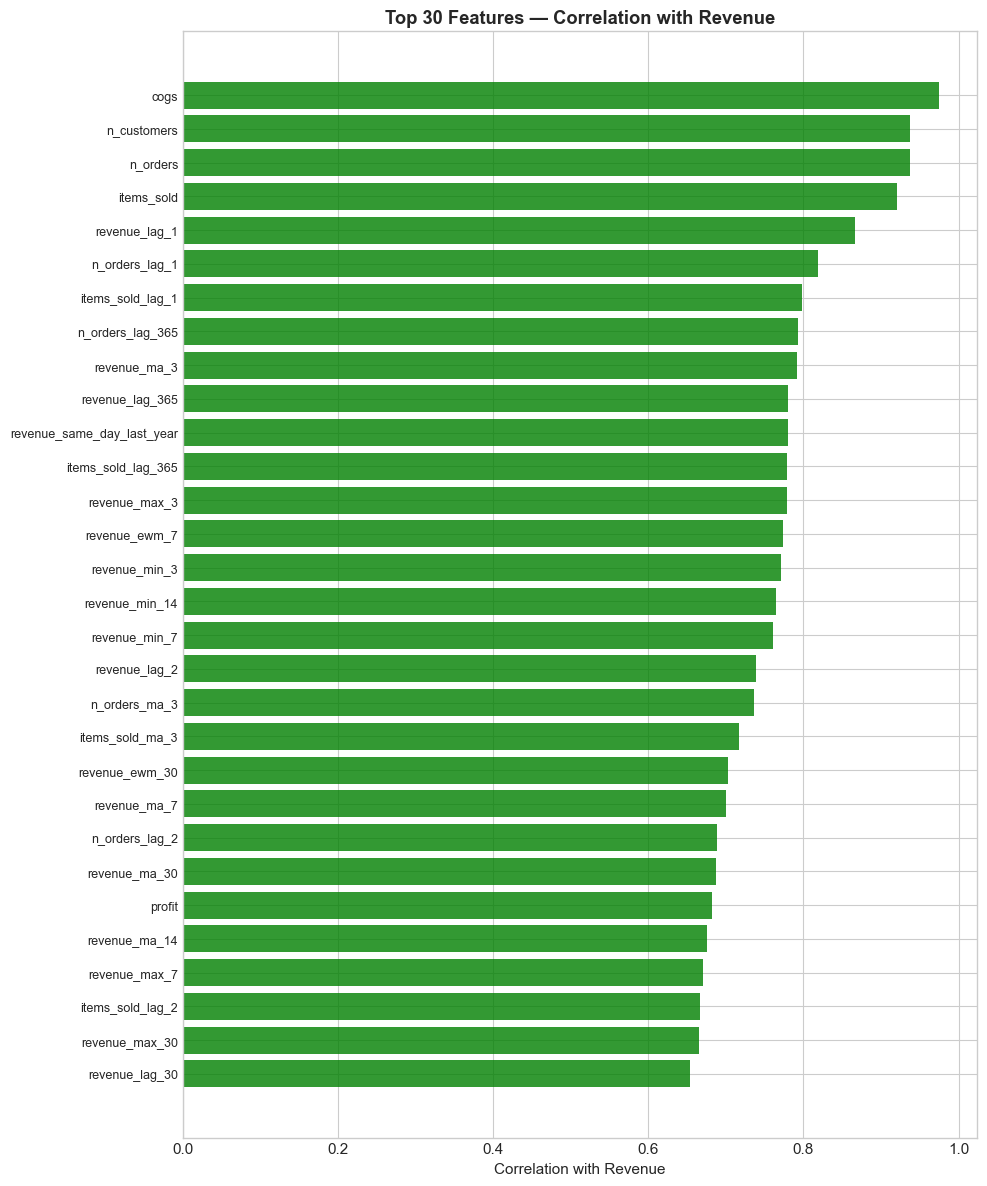


Top 15 features correlated with Revenue:
    1.                                     cogs: +0.9750
    2.                              n_customers: +0.9379
    3.                                 n_orders: +0.9371
    4.                               items_sold: +0.9208
    5.                            revenue_lag_1: +0.8659
    6.                           n_orders_lag_1: +0.8192
    7.                         items_sold_lag_1: +0.7987
    8.                         n_orders_lag_365: +0.7934
    9.                             revenue_ma_3: +0.7923
   10.                          revenue_lag_365: +0.7795
   11.               revenue_same_day_last_year: +0.7795
   12.                       items_sold_lag_365: +0.7794
   13.                            revenue_max_3: +0.7784
   14.                            revenue_ewm_7: +0.7740
   15.                            revenue_min_3: +0.7711


In [13]:
# === Top Correlated Features with Revenue ===
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [c for c in numeric_features if c != 'revenue' and df_clean[c].std() > 0]

correlations = df_clean[numeric_features].corrwith(df_clean['revenue']).dropna().sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
top_n = 30
top_corr = correlations.head(top_n)
colors = ['green' if v > 0 else 'red' for v in top_corr.values]
ax.barh(range(len(top_corr)), top_corr.values, color=colors, alpha=0.8)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index, fontsize=9)
ax.set_xlabel('Correlation with Revenue')
ax.set_title(f'Top {top_n} Features — Correlation with Revenue', fontweight='bold')
ax.invert_yaxis()
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f'\nTop 15 features correlated with Revenue:')
for i, (feat, corr) in enumerate(correlations.head(15).items()):
    print(f'   {i+1:>2}. {feat:>40}: {corr:>+.4f}')

In [14]:
# === Export Feature Dataset ===
output_path = DATA_DIR + 'features_daily_train.csv'
df_clean.to_csv(output_path, index=False)

print(f'Feature dataset exported: {output_path}')
print(f'   Shape: {df_clean.shape}')
print(f'   Date range: {df_clean.date.min().date()} → {df_clean.date.max().date()}')
print(f'\nReady for modeling!')

Feature dataset exported: ../dataset/features_daily_train.csv
   Shape: (3102, 169)
   Date range: 2013-07-05 → 2021-12-31

Ready for modeling!


---
## Tổng hợp — Feature Engineering

### Feature Categories Created
| Category | Count | Key Features |
|----------|-------|--------------|
| Calendar | ~16 | month, dow, is_weekend, is_tet_season, is_1111 |
| Lag | ~50 | revenue_lag_1/7/30, revenue_diff, pct_change |
| Rolling | ~50 | MA_7/30/90, std_7/30, ewm, CV |
| Fourier | ~14 | yearly/weekly/monthly sin/cos harmonics |
| Product | ~10 | category/segment share, avg_price |
| Customer | ~5 | active_customers, signups, new_ratio |
| External | ~10 | web_visits, promos, inventory |

### Model Recommendations
1. **LightGBM/XGBoost:** Sử dụng tất cả features → Feature importance sẽ chọn tự động
2. **Prophet:** Sử dụng calendar + Fourier + external regressors
3. **SARIMA:** Sử dụng differenced revenue (dựa trên kết quả Notebook 02)
4. **Ensemble:** Kết hợp 3 models trên cho prediction cuối cùng

### Next Steps
1. Train LightGBM với feature dataset
2. Feature importance analysis → Loại bỏ features kém
3. Hyperparameter tuning
4. Validate trên Validation Set (2022)
5. Generate test predictions

> **Output:** `features_daily_train.csv` — sẵn sàng cho modeling pipeline